## In this notebook i will explore the EllipticBitcoinDataset and understand how its constructed and the nature of the graph. This will lay the groundwork for the loader and the models i will train.

In [63]:
!pip install torch_geometric


In [64]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch_geometric
from torch_geometric.datasets import EllipticBitcoinDataset

print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)

PyTorch: 2.11.0+cpu
PyG: 2.8.0.post1


In [65]:
dataset = EllipticBitcoinDataset(root="../data/elliptic")

print(dataset)
print("Number of graphs:", len(dataset))

EllipticBitcoinDataset()
Number of graphs: 1


In [66]:
data=dataset[0]
print(data)
print("\n")
print(data.keys())

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])


['y', 'x', 'train_mask', 'edge_index', 'test_mask']


In [67]:
print("x:", data.x.shape)
print("\n")
print("edge_index:", data.edge_index.shape)
print("\n")
print("y:", data.y.shape)
print("\n")
print("train_mask:", data.train_mask.shape)
print("\n")
print("test_mask:", data.test_mask.shape)

x: torch.Size([203769, 165])


edge_index: torch.Size([2, 234355])


y: torch.Size([203769])


train_mask: torch.Size([203769])


test_mask: torch.Size([203769])


In [68]:
node_id = 0

print("Features:")
print(data.x[node_id])

print("\nLabel:")
print(data.y[node_id])

Features:
tensor([-1.7147e-01, -1.8467e-01, -1.2014e+00, -1.2197e-01, -4.3875e-02,
        -1.1300e-01, -6.1584e-02, -1.6210e-01, -1.6793e-01, -4.9707e-02,
        -1.6440e-01, -2.8741e-02, -3.5391e-02, -4.2955e-02, -1.3282e-02,
        -5.7195e-02, -1.6961e-01, -1.7115e-01, -1.7447e-01, -1.3737e+00,
        -1.3715e+00, -1.3973e-01, -1.4891e-01, -8.0147e-02, -1.5566e-01,
        -1.0763e-02, -1.2107e-02, -1.3973e-01, -1.4891e-01, -8.0147e-02,
        -1.5566e-01, -1.0669e-02, -1.2005e-02, -2.4669e-02, -3.1272e-02,
        -2.3045e-02, -2.6215e-02,  1.4278e-03,  1.4826e-03, -2.2722e-01,
        -2.3937e-01, -7.5256e-02, -2.3495e-01,  3.7468e-02,  4.3444e-02,
        -2.2720e-01, -2.4324e-01, -9.7895e-02, -2.3590e-01,  3.6577e-02,
         4.2345e-02, -4.1401e-01, -4.8834e-01, -2.3255e-01, -4.6755e-01,
         4.8767e-02,  5.2956e-02, -3.9149e-02, -1.7290e-01, -1.6313e-01,
        -1.6093e-01, -1.3163e+00, -1.3154e+00, -3.9144e-02, -1.7288e-01,
        -1.6311e-01, -1.6093e-01, -1.3163

## Here i will have a look at the class distribution

0 42019
1 4545
2 157205


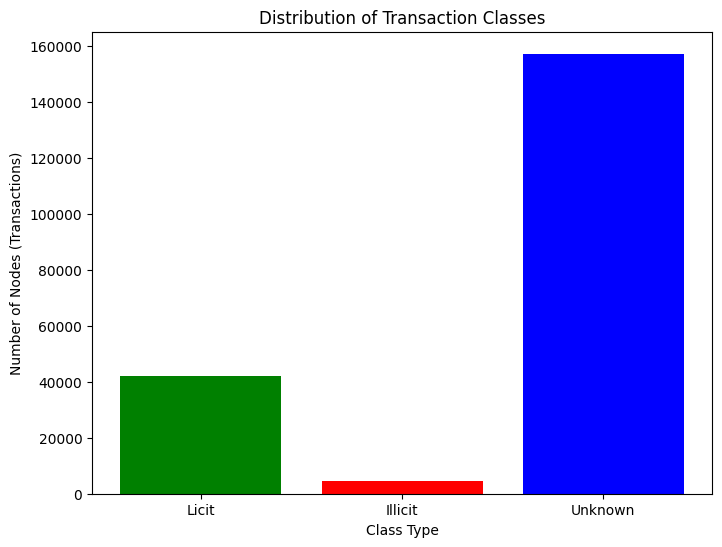

In [69]:
labels, counts = torch.unique(data.y, return_counts=True)

for label, count in zip(labels.tolist(), counts.tolist()):
    print(label, count)

class_names = {0: 'Licit', 1: 'Illicit', 2: 'Unknown'}
plot_labels = [class_names[label] for label in labels.tolist()]

plt.figure(figsize=(8, 6))
plt.bar(plot_labels, counts.tolist(), color=['green', 'red', 'blue'])
plt.xlabel('Class Type')
plt.ylabel('Number of Nodes (Transactions)')
plt.title('Distribution of Transaction Classes')
plt.show()

## I am going to implement a split according to :

###Train       1–30

###Validation 31–34

##Test       35–49

## PyG provides its own split according to:
### Train       1–34 Test       35–49


## So I will have to explicitly recover timestep from the raw file.

In [70]:
dataset.raw_paths

['../data/elliptic/raw/elliptic_txs_features.csv',
 '../data/elliptic/raw/elliptic_txs_edgelist.csv',
 '../data/elliptic/raw/elliptic_txs_classes.csv']

In [71]:
features_raw = pd.read_csv(dataset.raw_paths[0],header=None
)

features_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [72]:
features_raw = features_raw.rename(columns={0: "txId", 1: "time_step"
    }
)

features_raw[["txId", "time_step"]].head(1000)

,txId,time_step
0,230425980,1
1,5530458,1
2,232022460,1
3,232438397,1
4,230460314,1
...,...,...
995,23316173,1
996,232417457,1
997,58836743,1
998,36566888,1


In [73]:
features_raw["time_step"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

## I create a tensor based on the timesteps 1-49

In [74]:
time_step=torch.tensor(features_raw["time_step"].to_numpy(),
    dtype=torch.long)

print(time_step.shape)
print(time_step.min(), time_step.max())

torch.Size([203769])
tensor(1) tensor(49)


## I exclude the classes = 2 where the label is unknown. I create my own split.

In [75]:
known = data.y != 2

train_mask = (
    (time_step >= 1) &
    (time_step <= 30) &
    known
)

val_mask = (
    (time_step >= 31) &
    (time_step <= 34) &
    known
)

test_mask = (
    (time_step >= 35) &
    (time_step <= 49) &
    known
)

In [76]:
from torch_geometric.utils import degree

src = data.edge_index[0]
dst = data.edge_index[1]

out_degree = degree(src, num_nodes=data.num_nodes)
in_degree = degree(dst, num_nodes=data.num_nodes)

print("Average in-degree:", in_degree.mean().item())
print("Average out-degree:", out_degree.mean().item())

print("Max in-degree:", in_degree.max().item())
print("Max out-degree:", out_degree.max().item())



Average in-degree: 1.1501013040542603
Average out-degree: 1.1501013040542603
Max in-degree: 284.0
Max out-degree: 472.0


## Here i look at edge degree for illicit and licit transactions

In [77]:
for label, name in [(0, "licit"), (1, "illicit")]:
    mask = data.y == label

    print(name,"mean in-degree:",in_degree[mask].mean().item(),"mean out-degree:",out_degree[mask].mean().item()
    )

licit mean in-degree: 1.909398078918457 mean out-degree: 1.1858206987380981
illicit mean in-degree: 1.269966959953308 mean out-degree: 0.7416941523551941


In [78]:
for label, name in [(0, "licit"), (1, "illicit")]:
    mask = data.y == label

    print(f"\n{name.upper()}")

    for q in [0.25, 0.5, 0.75, 0.9, 0.99]:
        print(
            f"{q:>4}:",
            "in =", torch.quantile(in_degree[mask], q).item(),
            "out =", torch.quantile(out_degree[mask], q).item()
        )


LICIT
0.25: in = 0.0 out = 1.0
 0.5: in = 1.0 out = 1.0
0.75: in = 1.0 out = 1.0
 0.9: in = 3.0 out = 2.0
0.99: in = 26.0 out = 7.0

ILLICIT
0.25: in = 0.0 out = 0.0
 0.5: in = 1.0 out = 1.0
0.75: in = 1.0 out = 1.0
 0.9: in = 1.0 out = 1.0
0.99: in = 4.0 out = 2.0


In [79]:
X_train = data.x[train_mask].numpy()
y_train = data.y[train_mask].numpy()

X_val = data.x[val_mask].numpy()
y_val = data.y[val_mask].numpy()

X_test = data.x[test_mask].numpy()
y_test = data.y[test_mask].numpy()

In [80]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(26905, 165) (26905,)
(2989, 165) (2989,)
(16670, 165) (16670,)


### Here I implement the XGboost baseline model

In [92]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score,precision_recall_curve,classification_report,confusion_matrix,precision_score, recall_score,precision_score, recall_score,
)

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


### Now i prepare the training, test and validation data

In [93]:
X_train = data.x[train_mask].numpy()
y_train = data.y[train_mask].numpy()

X_val = data.x[val_mask].numpy()
y_val = data.y[val_mask].numpy()

X_test = data.x[test_mask].numpy()
y_test = data.y[test_mask].numpy()

In [94]:
print("Train:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTest:")
print("X:", X_test.shape)
print("y:", y_test.shape)

Train:
X: (26905, 165)
y: (26905,)

Validation:
X: (2989, 165)
y: (2989,)

Test:
X: (16670, 165)
y: (16670,)


In [95]:
XGBmodel = XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=42,
)
XGBmodel

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [96]:
XGBmodel.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [97]:
print(XGBmodel.get_booster().num_boosted_rounds())

100


In [98]:
y_val_prob = XGBmodel.predict_proba(X_val)[:, 1]

In [99]:
y_val_prob[:20]

array([4.9083857e-05, 1.8382225e-03, 6.2404433e-04, 6.7439338e-05,
       7.5689572e-06, 3.4327331e-05, 1.4621322e-04, 9.9821621e-01,
       8.6023858e-05, 1.5632921e-03, 2.7150020e-04, 2.1908481e-05,
       2.7331557e-06, 4.9529099e-06, 2.3146656e-06, 8.9918531e-06,
       9.9404860e-01, 9.9987805e-01, 7.0501119e-01, 5.2341801e-01],
      dtype=float32)

In [100]:
val_pr_auc = average_precision_score(y_val,y_val_prob,
)

print("Validation PR-AUC:", val_pr_auc)

Validation PR-AUC: 0.9854604747103272


### Treshold grid search best balance found at treshold  at $0.2$.

In [101]:
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.85]:
    y_pred = (y_val_prob >= threshold).astype(int)

    from sklearn.metrics import precision_score, recall_score

    p = precision_score(y_val, y_pred)
    r = recall_score(y_val, y_pred)

    print(
        f"Threshold={threshold:.2f} "
        f"Precision={p:.3f} "
        f"Recall={r:.3f}"
    )

Threshold=0.10 Precision=0.919 Recall=0.978
Threshold=0.20 Precision=0.948 Recall=0.939
Threshold=0.30 Precision=0.962 Recall=0.907
Threshold=0.40 Precision=0.969 Recall=0.866
Threshold=0.50 Precision=0.975 Recall=0.833
Threshold=0.70 Precision=0.986 Recall=0.697
Threshold=0.85 Precision=0.991 Recall=0.654


In [102]:
from sklearn.metrics import average_precision_score

val_pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

print(f"Validation PR-AUC: {val_pr_auc:.4f}")

Validation PR-AUC: 0.9855


In [103]:
from sklearn.metrics import f1_score

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.85]:
    y_pred = (y_val_prob >= threshold).astype(int)

    f1 = f1_score(y_val, y_pred)

    print(
        f"Threshold={threshold:.2f} "
        f"F1={f1:.3f}"
    )

Threshold=0.10 F1=0.948
Threshold=0.20 F1=0.944
Threshold=0.30 F1=0.934
Threshold=0.40 F1=0.915
Threshold=0.50 F1=0.898
Threshold=0.70 F1=0.817
Threshold=0.85 F1=0.788


In [116]:
from sklearn.metrics import (average_precision_score,precision_score,recall_score,f1_score,
                             confusion_matrix,
                             classification_report,
)

y_test_prob = XGBmodel.predict_proba(X_test)[:, 1]

threshold = 0.2

y_test_pred = (y_test_prob >= threshold).astype(int)

## Lets test the model on the test data. This will be our baseline.

In [118]:
test_pr_auc = average_precision_score(y_test, y_test_prob,
)

print(f"Test PR-AUC: {test_pr_auc:.4f}")

test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Threshold: {threshold:.2f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")

cm = confusion_matrix(y_test, y_test_pred,
)

print(cm)


Test PR-AUC: 0.7943
Threshold: 0.20
Precision: 0.7688
Recall:    0.7368
F1:        0.7525
[[15347   240]
 [  285   798]]
